In [1]:
import os
import pandas as pd
import cv2
import torch
import torch.nn.utils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.model_selection import train_test_split
import json

print("All modules imported")

All modules imported


1205
1083
1061


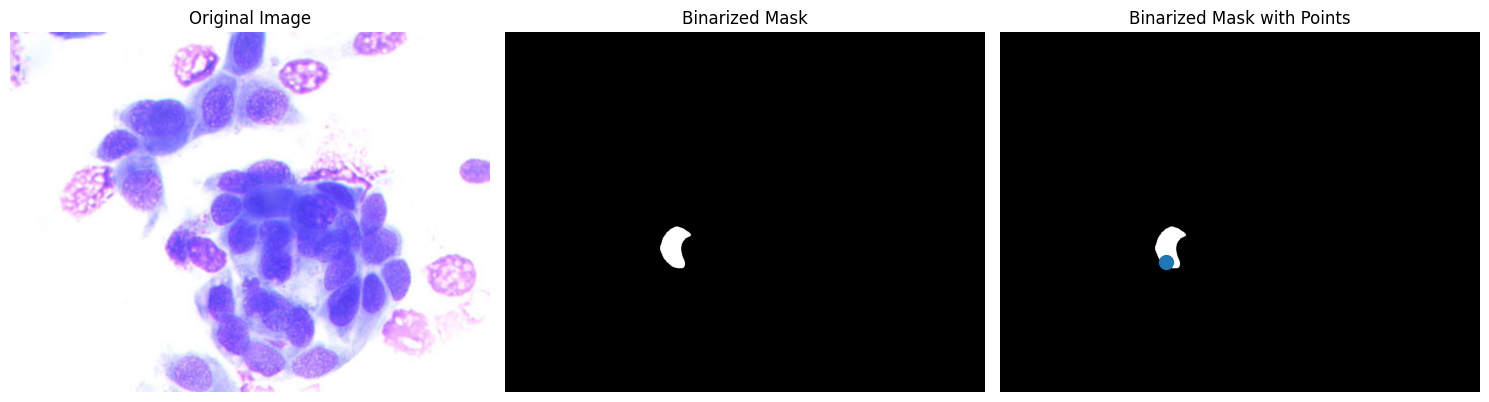

In [2]:
import os
import json
import numpy as np

train_data_dir = r"C:\Users\Admin\Desktop\Random_Train"
train_images_dir = os.path.join(train_data_dir, "images")
train_masks_dir = os.path.join(train_data_dir, "masks")
train_json_dir =os.path.join(train_data_dir,"labels.json")

with open(train_json_dir) as f:
    train_data=json.load(f)

train_all_data = []
train_all_images=[]
for entry in train_data['images']:
    image_name = entry['image_name']
    masks = [label['mask_file'] for label in entry['labels']]
    
    train_all_images.append({
        "image": os.path.join(train_images_dir, image_name),
        "masks": [os.path.join(train_masks_dir, mask) for mask in masks],
        "labels": [label['label'] for label in entry['labels']]
    })

train_final_data = []
for entry in train_all_images:
    for mask in entry['masks']:
        train_final_data.append({
            "image": entry["image"],
            "annotation": mask
        })
print(len(train_final_data))
####################################################################

vt_data_dir=r"C:\Users\Admin\Desktop\New_Dataset"
vt_images_dir= os.path.join(vt_data_dir,"images")
vt_masks_dir=os.path.join(vt_data_dir,"masks")
vt_json_dir=os.path.join(vt_data_dir,"labels.json")

with open(vt_json_dir) as f:
    vt_data=json.load(f)

vt_all_data=[]
vt_all_images=[]
for entry in vt_data['images']:
    image_name=entry['image_name']
    masks=[label['mask_file'] for label in entry['labels']]

    vt_all_images.append({
        "image":os.path.join(vt_images_dir, image_name),
        "masks": [os.path.join(vt_masks_dir, mask) for mask in masks],
        "labels":[label['label'] for label in entry['labels']]
    })
vt_final_data=[]
for entry in vt_all_images:
    for mask in entry['masks']:
        vt_final_data.append({
            "image": entry["image"],
            "annotation":mask
        })
print(len(vt_final_data))
###################################################################

test_data_dir = r"C:\Users\Admin\Desktop\New_Test_Dataset"
test_images_dir = os.path.join(test_data_dir, "images")
test_masks_dir = os.path.join(test_data_dir, "masks")
test_json_dir =os.path.join(test_data_dir,"labels.json")

with open(test_json_dir) as f:
    test_data=json.load(f)

test_all_data = []
test_all_images=[]
for entry in test_data['images']:
    image_name = entry['image_name']
    masks = [label['mask_file'] for label in entry['labels']]
    
    test_all_images.append({
        "image": os.path.join(test_images_dir, image_name),
        "masks": [os.path.join(test_masks_dir, mask) for mask in masks],
        "labels": [label['label'] for label in entry['labels']]
    })

test_final_data = []
for entry in test_all_images:
    for mask in entry['masks']:
        test_final_data.append({
            "image": entry["image"],
            "annotation": mask
        })
print(len(test_final_data))

def read_batch(data, visualize_data=False):
    # Select a random entry
    ent = data[np.random.randint(len(data))]

    # Get full paths
    Img = cv2.imread(ent["image"])[..., ::-1]  # Convert BGR to RGB
    ann_map = cv2.imread(ent["annotation"], cv2.IMREAD_GRAYSCALE)  # Read annotation as grayscale

    if Img is None or ann_map is None:
        print(f"Error: Could not read image or mask from path {ent['image']} or {ent['annotation']}")
        return None, None, None, 0

    # Resize image and mask
    r = np.min([1024 / Img.shape[1], 1024 / Img.shape[0]])  # Scaling factor
    Img = cv2.resize(Img, (int(Img.shape[1] * r), int(Img.shape[0] * r)))
    ann_map = cv2.resize(ann_map, (int(ann_map.shape[1] * r), int(ann_map.shape[0] * r)), interpolation=cv2.INTER_NEAREST)
    binary_mask = np.zeros_like(ann_map, dtype=np.uint8)
    points=[]
    inds = np.unique(ann_map)[1:]
    for ind in inds:
        mask = (ann_map == ind).astype(np.uint8)
        binary_mask = np.maximum(binary_mask, mask)
    coords = np.argwhere(binary_mask > 0)
    if len(coords) > 0:
        for _ in inds:
            yx = np.array(coords[np.random.randint(len(coords))])
            points.append([yx[1], yx[0]])
    points = np.array(points)

    if visualize_data:
        # Plotting the images and points
        plt.figure(figsize=(15, 5))

        # Original Image
        plt.subplot(1, 3, 1)
        plt.title('Original Image')
        plt.imshow(Img)
        plt.axis('off')
        # Segmentation Mask (binary_mask)
        plt.subplot(1, 3, 2)
        plt.title('Binarized Mask')
        plt.imshow(binary_mask, cmap='gray')
        plt.axis('off')

        # Mask with Points in Different Colors
        plt.subplot(1, 3, 3)
        plt.title('Binarized Mask with Points')
        plt.imshow(binary_mask, cmap='gray')
        colors = list(mcolors.TABLEAU_COLORS.values())
        for i, point in enumerate(points):
            plt.scatter(point[0], point[1], c=colors[i % len(colors)], s=100, label=f'Point {i+1}')  # Corrected to plot y, x order

        # plt.legend()
        plt.axis('off')

        plt.tight_layout()
        plt.show()
        
    binary_mask = np.expand_dims(binary_mask, axis=-1)  # Now shape is (1024, 1024, 1)
    binary_mask = binary_mask.transpose((2, 0, 1))
    points = np.expand_dims(points, axis=1)

    # Return the image, binarized mask, points, and number of masks
    return Img, binary_mask, points, len(inds)

Img1, masks1, points1, num_masks = read_batch(train_final_data, visualize_data=True)


In [3]:
def read_image(image_path, mask_path):  # read and resize image and mask
    img = cv2.imread(image_path)[..., ::-1]  # Convert BGR to RGB
    mask = cv2.imread(mask_path, 0)
    r = np.min([1024 / img.shape[1], 1024 / img.shape[0]])
    img = cv2.resize(img, (int(img.shape[1] * r), int(img.shape[0] * r)))
    mask = cv2.resize(mask, (int(mask.shape[1] * r), int(mask.shape[0] * r)), interpolation=cv2.INTER_NEAREST)
    return img, mask

def get_points(mask, num_points):  # Sample points inside the input mask
    points = []
    coords = np.argwhere(mask > 0)
    for i in range(num_points):
        yx = np.array(coords[np.random.randint(len(coords))])
        points.append([[yx[1], yx[0]]])
    return np.array(points)

In [4]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import random
from PIL import Image
from torchvision import transforms

train_all_data=[]
for entry in train_data['images']:
    image_name = entry['image_name']
    image_path = os.path.join(train_images_dir, image_name)

    image = Image.open(image_path).convert("RGB")

    for label_info in entry['labels']:
        mask_path = os.path.join(train_masks_dir, label_info['mask_file'])
        label = label_info['label']
        mask = Image.open(mask_path).convert("L")
        masked_image = Image.composite(image, Image.new("RGB", image.size), mask)
        masked_image = np.array(masked_image)
        train_all_data.append({"masked_image": masked_image, "label": label})
#################################################################################
val_test_data=[]
for entry in vt_data['images']:
    image_name=entry['image_name']
    image_path=os.path.join(vt_images_dir, image_name)
    image=Image.open(image_path).convert("RGB")

    for label_info in entry['labels']:
        mask_path=os.path.join(vt_masks_dir, label_info['mask_file'])
        label=label_info['label']
        mask=Image.open(mask_path).convert("L")
        masked_image=Image.composite(image, Image.new("RGB", image.size), mask)
        masked_image=np.array(masked_image)
        val_test_data.append({'masked_image':masked_image, 'label': label})
#################################################################################
test_all_data=[]
for entry in test_data['images']:
    image_name= entry['image_name']
    image_path= os.path.join(test_images_dir, image_name)

    image=Image.open(image_path).convert("RGB")

    for label_info in entry['labels']:
        mask_path=os.path.join(test_masks_dir, label_info['mask_file'])
        label=label_info['label']

        mask=Image.open(mask_path).convert("L")

        masked_image = Image.composite(image, Image.new("RGB", image.size), mask)
        masked_image = np.array(masked_image)

        test_all_data.append({"masked_image":masked_image, "label":label})
        
#label_mapping = {"epithelial": 1, "muciparous": 2, "artefatto": 3, "neutrophil": 4, 
#                 "epithelial ciliated": 5, "emazia": 6, "metaplastic": 7, "eosinophil": 8, 
#                 "mast cell": 9, "lymphocyte": 10}


copies_per_class={"epithelial":1,
                  "neutrophil": 1,
                  "artefatto": 5,
                  "muciparous":10,
                  "eosinophil":10,
                  "metaplastic": 10,
                  "epithelial ciliated": 10,
                  "lymphocyte": 10,
                  "mast cell": 10,
                  "emazia" : 10
                 }

class MaskedImageDataset(torch.utils.data.Dataset):
    def __init__(self, data, transform=None, augmentations=None, copies_per_class=None):

        self.data = data
        self.transform = transform
        self.augmentations = augmentations
        self.copies_per_class = copies_per_class or {}
        self.expanded_data = self._expand_data()
    
    def _expand_data(self):
        expanded_data = []
        for item in self.data:
            label = item["label"]
            num_copies = self.copies_per_class.get(label, 1)
            expanded_data.append(item)
            
            for _ in range(num_copies - 1):
                augmented_item = item.copy()
                image = item["masked_image"]
                
                if not isinstance(image, np.ndarray):
                    image = np.array(image)

                if self.augmentations:
                    augmented_data = self.augmentations(image=image)
                    augmented_item["masked_image"] = augmented_data["image"]

                expanded_data.append(augmented_item)

        return expanded_data

    def __getitem__(self, idx):
        item = self.expanded_data[idx]
        masked_image = item["masked_image"]
        label = item["label"]

        if self.augmentations and isinstance(masked_image, np.ndarray):
            masked_image = np.array(masked_image)

        #if self.augmentations:
        #    augmented = self.augmentations(image=masked_image)
        #    masked_image = augmented["image"]

        masked_image = torch.tensor(masked_image, dtype=torch.float32)

        if self.transform and not isinstance(masked_image, torch.Tensor):
            masked_image = self.transform(masked_image)

        return masked_image, label

    def __len__(self):
        return len(self.expanded_data)


albumentations_augmentations = A.Compose([
    A.RandomBrightnessContrast(p=1.0),
    A.VerticalFlip(p=0.5)
])

torchvision_transform = transforms.Compose([
    transforms.ToTensor(),
    ToTensorV2()
])

train_dataset = MaskedImageDataset(
    train_all_data,
    augmentations=albumentations_augmentations,
    copies_per_class=copies_per_class
)

#train_dataset = MaskedImageDataset(
#    train_all_data,
#    #val_test_data,
#    transform=torchvision_transform, 
#    augmentations=albumentations_augmentations, 
#    num_copies=4
#)

final_test_dataset= MaskedImageDataset(
    test_all_data,
    transform=torchvision_transform
)

test_dataset=MaskedImageDataset(
    val_test_data,
    #train_all_data,
    transform=torchvision_transform
)

final_test_loader=torch.utils.data.DataLoader(final_test_dataset, batch_size=4, shuffle=True)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=4, shuffle=False)

C:\Users\Admin\anaconda3\envs\NC_Torch\Lib\site-packages\albumentations\__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.24 (you have 1.4.21). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [5]:
len(train_all_data)

1205

torch.Size([768, 1024, 3])


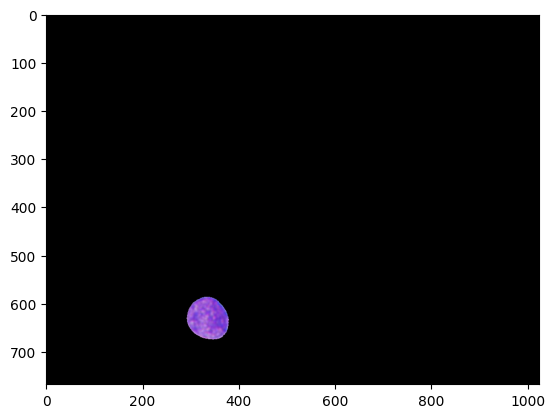

In [6]:
import cv2
data_iter = iter(train_loader)
images, labels = next(data_iter)

image = images[2]
label = labels[2]
print(image.shape) 

image=image.numpy()

image_np = (image * 1).astype(np.uint8)

plt.imshow(image_np)
plt.show()

In [7]:
import timm
classifier = timm.create_model('inception_v4', pretrained=True, num_classes=10)

In [8]:
#print(classifier)

In [9]:
import torch.nn as nn
new_classifier = nn.Sequential(
    nn.Linear(classifier.last_linear.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.1),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.1),
    nn.Linear(256, 10)
)
classifier.last_linear=new_classifier
#print(classifier)

In [10]:
child_counter = 0
for child in classifier.children():
   #print(" child", child_counter, "is:")
   #print(child)
   child_counter += 1

In [11]:
import torch.nn as nn
def freeze_children(model, n):
    num_frozen = 0
    for name, param in model.named_parameters():
        if num_frozen < n:
            param.requires_grad = False
            num_frozen += 1
        else:
            break
    
freeze_children(classifier,0)
count=0
for name, param in classifier.named_parameters():
  #print(f"Layer: {name}, requires_grad: {param.requires_grad}")
  count+=1

print(count)

453



=== Fold 1/4 ===


Fold 1 Epoch [1/30] - Loss: 0.4215, Training Accuracy: 39.96%
Epoch validation accuracy: 57.571
Epoch's tentative final test accuracy:  67.861


Fold 1 Epoch [2/30] - Loss: 0.3135, Training Accuracy: 57.26%
Epoch validation accuracy: 65.457
Epoch's tentative final test accuracy:  69.274


Fold 1 Epoch [3/30] - Loss: 0.2642, Training Accuracy: 65.19%
Epoch validation accuracy: 70.505
Epoch's tentative final test accuracy:  69.369


Fold 1 Epoch [4/30] - Loss: 0.2275, Training Accuracy: 70.24%
Epoch validation accuracy: 66.404
Epoch's tentative final test accuracy:  72.196


...

Fold 4 Epoch [26/30] - Loss: 0.0162, Training Accuracy: 98.32%
Epoch validation accuracy: 92.271
Epoch's tentative final test accuracy:  73.327


Fold 4 Epoch [27/30] - Loss: 0.0210, Training Accuracy: 97.90%
Epoch validation accuracy: 88.013
Epoch's tentative final test accuracy:  72.102


Fold 4 Epoch [28/30] - Loss: 0.0330, Training Accuracy: 96.64%
Epoch validation accuracy: 89.274
Epoch's tentative final test accuracy:  71.725


Fold 4 Epoch [29/30] - Loss: 0.0269, Training Accuracy: 96.79%
Epoch validation accuracy: 89.905
Epoch's tentative final test accuracy:  71.631


Fold 4 Epoch [30/30] - Loss: 0.0231, Training Accuracy: 97.58%
Epoch validation accuracy: 92.744
Epoch's tentative final test accuracy:  73.327
Fold 4 Validation Accuracy: 92.74%, Test Accuracy: 70.08%

=== Cross-Validation Results ===
Average Validation Accuracy: 93.14%
Average Test Accuracy: 69.48%


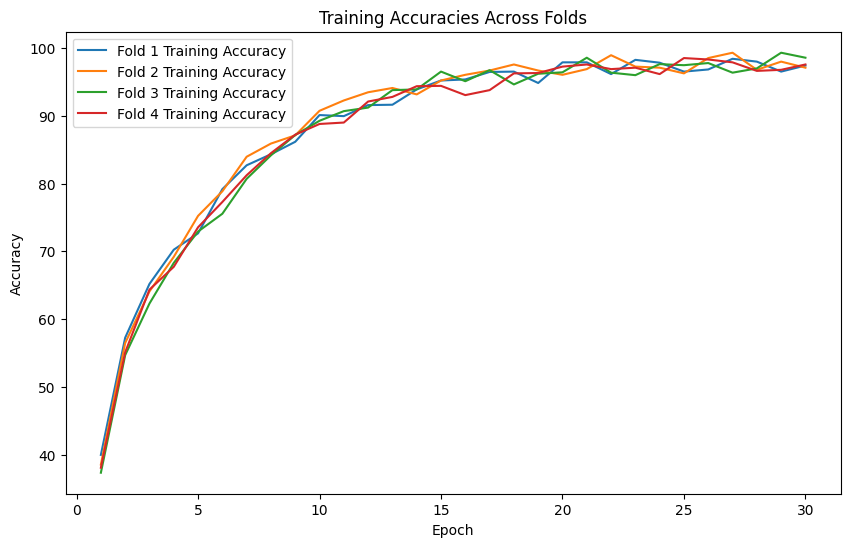

In [13]:
from torch.optim import SGD, Adam
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from torch.utils.data import Subset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

k=4
batch_size=4
fold_train_accuracies = []
fold_val_accuracies = []
fold_t_accuracies = []
fold_test_accuracies=[]
dataset = train_dataset

kf = KFold(n_splits=k, shuffle=True, random_state=42)

num_classes = 10
classifier = timm.create_model('inception_v4', pretrained=True, num_classes=10)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
classifier.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = Adam(classifier.parameters(), lr=0.00005)
num_epochs = 30

label_mapping = {"epithelial": 1, "muciparous": 2, "artefatto": 3, "neutrophil": 4, 
                 "epithelial ciliated": 5, "emazia": 6, "metaplastic": 7, "eosinophil": 8, 
                 "mast cell": 9, "lymphocyte": 10}

train_accuracies, test_accuracies, train_losses = [], [], []
checkpoint_dir = r"C:\Users\Admin\Documents\inceptionv4_alb_checks"

for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
    best_fva=0
    print(f"\n=== Fold {fold+1}/{k} ===")

    train_subset = torch.utils.data.Subset(dataset, train_idx)
    val_subset = torch.utils.data.Subset(dataset, val_idx)
    train_loader_kfold = torch.utils.data.DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader_kfold = torch.utils.data.DataLoader(val_subset, batch_size=batch_size, shuffle=False)

    # Reinitializing model, optimizer, scheduler and criterion for each fold
    classifier = timm.create_model('inception_v4', pretrained=True, num_classes=10)
    #classifier.last_linear = new_classifier
    #print(classifier)
    freeze_children(classifier, 0) 
    classifier.to(device)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(classifier.parameters(), lr=0.00005)

    
    # Training Loop
    fold_train_accuracy = []
    fold_val_accuracy = []
    fold_t_accuracy=[]
    for epoch in range(num_epochs):
        classifier.train()
        running_loss = 0.0
        correct_predictions = 0
        total_predictions = 0
        total_val_loss=0.0
        total_t_loss=0.0
        progress_bar = tqdm(train_loader_kfold, desc=f"Fold {fold+1} Epoch {epoch+1}/{num_epochs}", leave=False)
        
        # Processing one epoch within each fold
        for masked_images, labels in progress_bar:
            masked_images = masked_images.permute(0, 3, 1, 2)
            masked_images = masked_images.to(device)
            optimizer.zero_grad()

            outputs = classifier(masked_images)
            #print("Training outputs:")
            #print(outputs)
            #outputs=outputs.logits
            numeric_labels = torch.tensor([label_mapping[label] - 1 for label in labels],dtype=torch.long, device=device)
            loss = criterion(outputs, numeric_labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_predictions += (predicted == numeric_labels).sum().item()
            total_predictions += len(numeric_labels)

            avg_loss = running_loss / total_predictions
            accuracy = correct_predictions / total_predictions * 100
            progress_bar.set_postfix(loss=avg_loss, accuracy=f"{accuracy:.2f}%")
            
        # Printing epoch metrics
        print(f"Fold {fold+1} Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f}, Training Accuracy: {accuracy:.2f}%")
        fold_train_accuracy.append(accuracy)  # Appending accuracy of each epoch to one list
        
        # Getting validation results for the epoch
        classifier.eval()
        correct_val_predictions, total_val_predictions = 0, 0
        correct_t_predictions, total_t_predictions=0,0
        with torch.no_grad():
            for masked_images, labels in val_loader_kfold:
                masked_images = masked_images.permute(0, 3, 1, 2)
                masked_images = masked_images.to(device)
                outputs = classifier(masked_images)
                #print("validation outputs: ")
                #print(outputs)
                # outputs=outputs.logits
                numeric_labels = torch.tensor([label_mapping[label] - 1 for label in labels],dtype=torch.long, device=device)
                _, predicted = torch.max(outputs, 1)
                correct_val_predictions += (predicted == numeric_labels).sum().item()
                total_val_predictions += len(numeric_labels)
                loss = criterion(outputs, numeric_labels)
                total_val_loss += loss.item()

            for masked_images, labels in final_test_loader:
                masked_images=masked_images.permute(0,3,1,2)
                masked_images=masked_images.to(device)
                outputs=classifier(masked_images)
                numeric_labels=torch.tensor([label_mapping[label] - 1 for label in labels],dtype=torch.long, device=device)
                _, predicted=torch.max(outputs,1)
                correct_t_predictions+=(predicted == numeric_labels).sum().item()
                total_t_predictions+=len(numeric_labels)
                loss=criterion(outputs, numeric_labels)
                total_t_loss+=loss.item()

        average_val_loss = total_val_loss / len(val_loader_kfold)
        val_accuracy = correct_val_predictions / total_val_predictions * 100
        print(f"Epoch validation accuracy: {val_accuracy:.3f}")

        average_t_loss=total_t_loss/len(final_test_loader)
        scheduler.step(average_val_loss) # Implementing Reduce LR On Plateau here
        t_accuracy= correct_t_predictions/total_t_predictions * 100
        print(f"Epoch's tentative final test accuracy: {t_accuracy: .3f}")
        
        fold_val_accuracy.append(val_accuracy) # Appending epoch validation accuracy to one list
        fold_t_accuracy.append(t_accuracy)
        if val_accuracy>best_fva:
            best_fva=t_accuracy
            checkpoint_path = os.path.join(checkpoint_dir, f"classifier_epoch_{epoch+1}_fold{fold+1}_{t_accuracy:.3f}.pth") # Saving
            torch.save(classifier.state_dict(), checkpoint_path)
            
    # Appending the list of all epoch accuracies in a fold to another list of fold accuracies
    fold_train_accuracies.append(fold_train_accuracy)
    fold_val_accuracies.append(fold_val_accuracy)
    # Evaluation on test_loader, once per each fold
    correct_test_predictions, total_test_predictions = 0, 0
    classifier.eval()
    with torch.no_grad():
        for masked_images, labels in test_loader:
            masked_images=masked_images.permute(0,3,1,2)
            masked_images = masked_images.to(device)
            outputs = classifier(masked_images)
            #outputs= outputs.logits
            numeric_labels = torch.tensor([label_mapping[label] - 1 for label in labels],dtype=torch.long, device=device)
            _, predicted = torch.max(outputs, 1)
            correct_test_predictions += (predicted == numeric_labels).sum().item()
            total_test_predictions += len(numeric_labels)

    test_accuracy = correct_test_predictions / total_test_predictions * 100
    fold_test_accuracies.append(test_accuracy)
    # checkpoint_path = os.path.join(checkpoint_dir, f"classifier_epoch_{epoch+1}_TA_{test_accuracy}_FVA_{fold_val_accuracy[-1]}.pth")
    # Printing the fold's best validation and test accuracy
    print(f"Fold {fold+1} Validation Accuracy: {fold_val_accuracy[-1]:.2f}%, Test Accuracy: {test_accuracy:.2f}%")

# Cross-Validation Summary
print("\n=== Cross-Validation Results ===")
avg_val_accuracy = sum([acc[-1] for acc in fold_val_accuracies]) / k
avg_test_accuracy = sum(fold_test_accuracies) / k
print(f"Average Validation Accuracy: {avg_val_accuracy:.2f}%")
print(f"Average Test Accuracy: {avg_test_accuracy:.2f}%")

plt.figure(figsize=(10, 6))
for fold_idx, train_acc in enumerate(fold_train_accuracies):
    plt.plot(range(1, num_epochs + 1), train_acc, label=f"Fold {fold_idx + 1} Training Accuracy")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Accuracies Across Folds')
plt.show()

In [14]:
print("Fold Test Accuracies: ", fold_test_accuracies)

Fold Test Accuracies:  [70.08310249307479, 69.3444136657433, 68.42105263157895, 70.08310249307479]


In [ ]:
label_mapping = {"epithelial": 1, "muciparous": 2, "artefatto": 3, "neutrophil": 4, 
                 "epithelial ciliated": 5, "emazia": 6, "metaplastic": 7, "eosinophil": 8, 
                 "mast cell": 9, "lymphocyte": 10}

model=timm.create_model('inception_v4', pretrained=True, num_classes=10)
# model.fc = new_classifier
saved_model_path=r"C:\Users\Admin\Documents\inception_v4_checks\classifier_epoch_8_fold1_80.664.pth"


model.load_state_dict(torch.load(checkpoint_path))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
correct = 0
total = 0

with torch.no_grad():
    for masked_images,labels in final_test_loader:
        masked_images=masked_images.permute(0,3,1,2)
        masked_images=masked_images.to(device)
        outputs = model(masked_images)
        numeric_labels = torch.tensor([label_mapping[label] - 1 for label in labels],dtype=torch.long, device=device)
        _, predicted = torch.max(outputs, 1)
    
        total += len(numeric_labels)
        correct += (predicted == numeric_labels).sum().item()
   
accuracy = 100 * correct / total
print("Evaluating for ", checkpoint_path)
print(f"Accuracy on test dataset is : {accuracy:.3f}%")

In [ ]:
label_mapping = {"epithelial": 1, "muciparous": 2, "artefatto": 3, "neutrophil": 4, 
                 "epithelial ciliated": 5, "emazia": 6, "metaplastic": 7, "eosinophil": 8, 
                 "mast cell": 9, "lymphocyte": 10}

model=timm.create_model('inception_v4', pretrained=True, num_classes=10)
# model.fc = new_classifier
#saved_model_path=r"C:\Users\Admin\Documents\inceptionv3_checks\classifier_epoch_34_fold1_76.331.pth"

for checkpoint in os.scandir(r"C:\Users\Admin\Documents\inceptionv3_checks"):
    checkpoint_path=checkpoint.path
    model.load_state_dict(torch.load(checkpoint_path))
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    correct = 0
    total = 0

    with torch.no_grad():
        for masked_images,labels in final_test_loader:
            masked_images=masked_images.permute(0,3,1,2)
            masked_images=masked_images.to(device)
            outputs = model(masked_images)
            numeric_labels = torch.tensor([label_mapping[label] - 1 for label in labels],dtype=torch.long, device=device)
            _, predicted = torch.max(outputs, 1)
    
            total += len(numeric_labels)
            correct += (predicted == numeric_labels).sum().item()
   
    accuracy = 100 * correct / total
    print("Evaluating for ", checkpoint_path)
    print(f"Accuracy on test dataset is : {accuracy:.3f}%")